# Model fitting: Leptonic equilibrium SSC

In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pylab as plt
import jetset
from jetset.test_data_helper import  test_SEDs
from jetset.data_loader import ObsData,Data
from jetset.plot_sedfit import PlotSED
from jetset.test_data_helper import  test_SEDs

In [2]:
print(jetset.__version__)

1.4.0rc3


In [3]:
test_SEDs

['/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_3C345.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk421_EBL_DEABS.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk501_EBL_ABS.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk501_EBL_DEABS.ecsv']

## Loading data



In [4]:
print(test_SEDs[1])
data=Data.from_file(test_SEDs[1])


/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk421_EBL_DEABS.ecsv



***  binning data  ***
---> N bins= 88
---> bin_width= 0.2



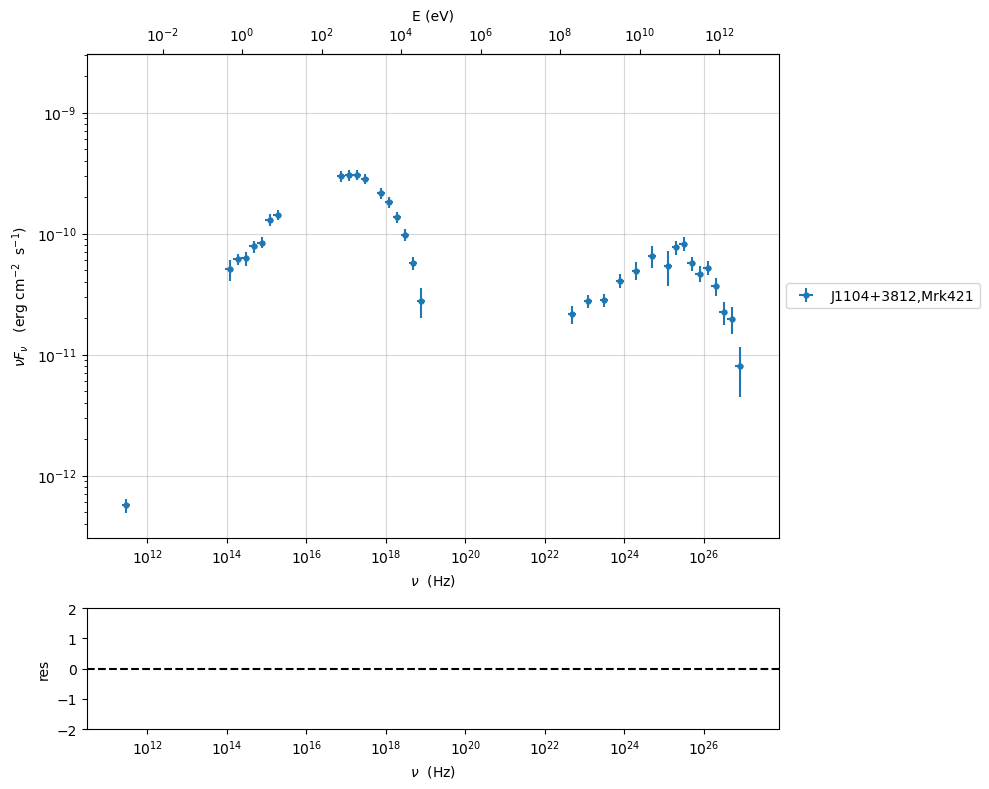

In [5]:
%matplotlib inline
sed_data=ObsData(data_table=data)
sed_data.group_data(bin_width=0.2)

sed_data.add_systematics(0.1,[10.**6,10.**29])
p=sed_data.plot_sed()
#p.setlim(y_min=1E-15,x_min=1E7,x_max=1E29)

In [6]:
sed_data.save('Mrk_401.pkl')

## phenomenological model constraining

### spectral indices


*** evaluating spectral indices for data ***



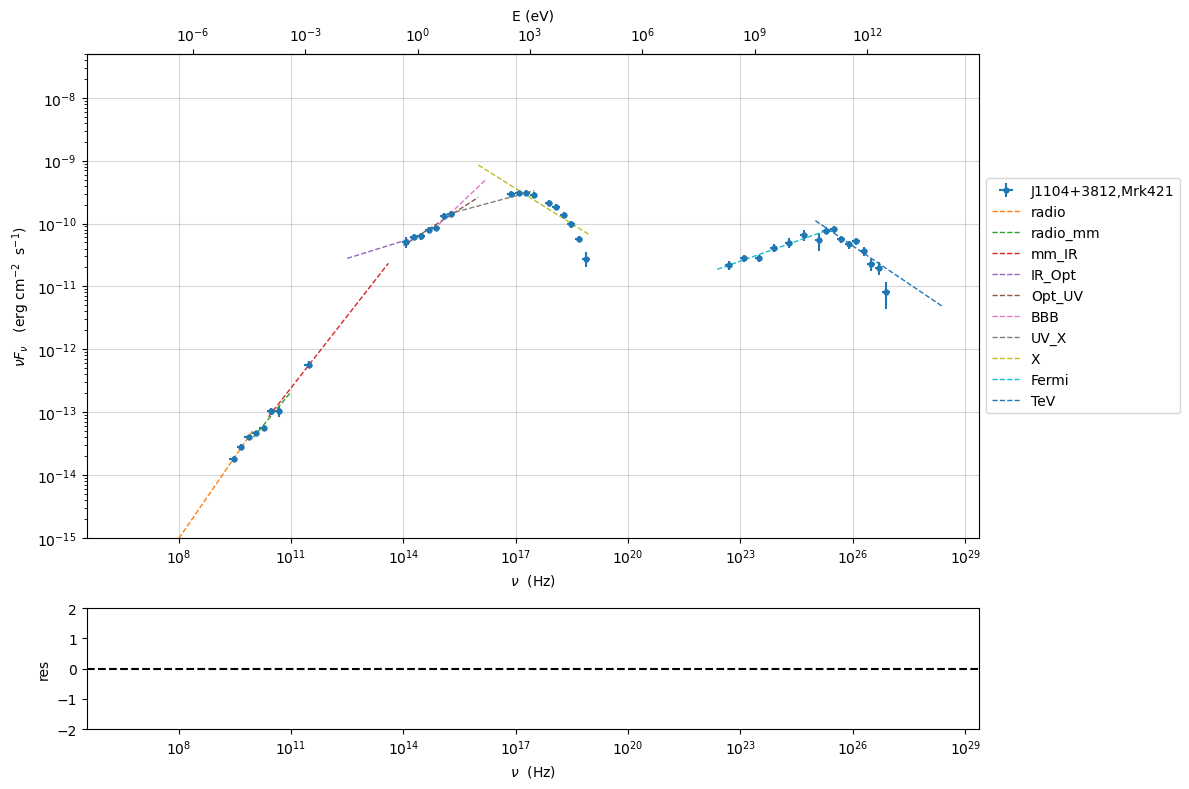

In [7]:
from jetset.sed_shaper import  SEDShape
my_shape=SEDShape(sed_data)
my_shape.eval_indices(minimizer='lsb',silent=True)
p=my_shape.plot_indices()
p.setlim(y_min=1E-15,y_max=5E-8)

### sed shaper

In [8]:
mm,best_fit=my_shape.sync_fit(check_host_gal_template=False,
                  Ep_start=None,
                  minimizer='lsb',
                  silent=True,
                  fit_range=[10.,21.])


*** Log-Polynomial fitting of the synchrotron component ***
---> first blind fit run,  fit range: [10.0, 21.0]
---> class:  HSP





model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
LogCubic,b,-1.563747e-01,-1.563747e-01,5.975434e-03,--,-1.000000e+00,-1.000000e+01,0.000000e+00,False
LogCubic,c,-1.052802e-02,-1.052802e-02,8.781942e-04,--,-1.000000e+00,-1.000000e+01,1.000000e+01,False
LogCubic,Ep,1.675324e+01,1.675324e+01,2.396636e-02,--,1.670206e+01,0.000000e+00,3.000000e+01,False
LogCubic,Sp,-9.494365e+00,-9.494365e+00,1.704982e-02,--,-1.000000e+01,-3.000000e+01,0.000000e+00,False


---> sync       nu_p=+1.675324e+01 (err=+2.396636e-02)  nuFnu_p=-9.494365e+00 (err=+1.704982e-02) curv.=-1.563747e-01 (err=+5.975434e-03)




*** Log-Polynomial fitting of the IC component ***
---> fit range: [23.0, 29.0]
---> LogCubic fit




model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
LogCubic,b,-2.274590e-01,-2.274590e-01,3.262166e-02,--,-1.000000e+00,-1.000000e+01,0.000000e+00,False
LogCubic,c,-6.259967e-02,-6.259967e-02,1.629408e-02,--,-1.000000e+00,-1.000000e+01,1.000000e+01,False
LogCubic,Ep,2.527207e+01,2.527207e+01,8.149547e-02,--,2.528644e+01,0.000000e+00,3.000000e+01,False
LogCubic,Sp,-1.014119e+01,-1.014119e+01,2.734754e-02,--,-1.000000e+01,-3.000000e+01,0.000000e+00,False


---> IC         nu_p=+2.527207e+01 (err=+8.149547e-02)  nuFnu_p=-1.014119e+01 (err=+2.734754e-02) curv.=-2.274590e-01 (err=+3.262166e-02)



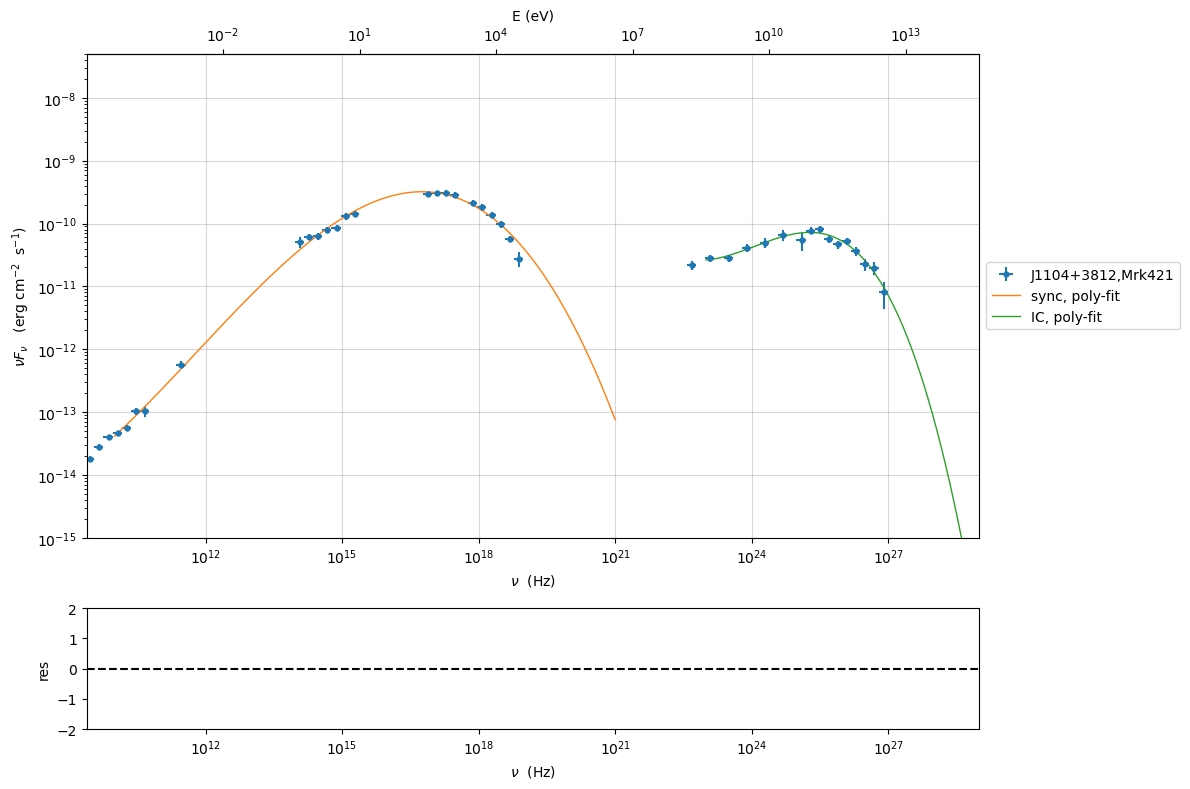

In [9]:
my_shape.IC_fit(fit_range=[23.,29.],minimizer='minuit',silent=True)
p=my_shape.plot_shape_fit()
p.setlim(y_min=1E-15,y_max=5E-8)

### Model constraining

In this step we are not fitting the model, we are just obtaining the phenomenological `pre_fit` model, that will be fitted in using minuit ore least-square bound, as shown below

In [10]:
from jetset.obs_constrain import ObsConstrain


sed_obspar=ObsConstrain(beaming=25,
                        B_range=[0.001,0.1],
                        t_var_sec=3*86400,
                        nu_cut_IR=1E12,
                        distr_e='bkn',
                        SEDShape=my_shape)


prefit_jet=sed_obspar.constrain_SSC_model(electron_distribution_log_values=False,silent=True)
prefit_jet.save_model('prefit_jet.pkl')


***  constrains parameters from observable ***



model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,R,region_size,cm,2.219270e+16,1.000000e+03,1.000000e+30,False,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,6.618390e-02,0.000000e+00,--,False,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,,2.500000e+01,1.000000e-04,--,False,False
jet_leptonic,z_cosm,redshift,,3.080000e-02,0.000000e+00,--,False,False
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,4.103365e+02,1.000000e+00,1.000000e+09,False,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,1.136207e+06,1.000000e+00,1.000000e+15,False,False
jet_leptonic,N,emitters_density,1 / cm3,1.238758e+00,0.000000e+00,--,False,False
jet_leptonic,gamma_break,turn-over-energy,lorentz-factor*,9.766963e+04,1.000000e+00,1.000000e+09,False,False


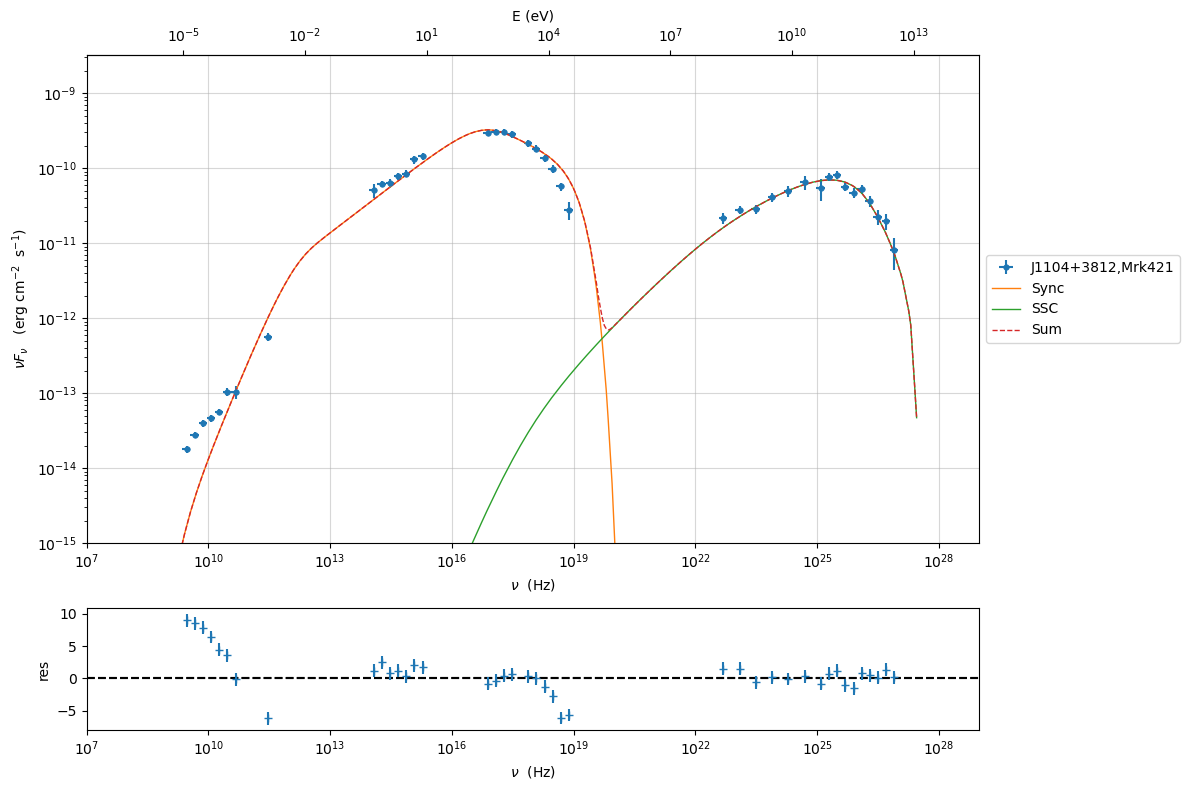

In [11]:
prefit_jet.eval()
pl=prefit_jet.plot_model(sed_data=sed_data)
pl.add_residual_plot(prefit_jet,sed_data)
pl.setlim(y_min=1E-15,x_min=1E7,x_max=1E29)

## Enabling the leptonic equilibrium

We change the emitters distribution for the `prefit_jet` model. We just preserve the original values of `gmin` and `gmax`

In [12]:
from jetset.jet_emitters_factory import InjEmittersFactory

gmin=prefit_jet.parameters.gmin.val
gmax=prefit_jet.parameters.gmax.val

q_inj = InjEmittersFactory().create_inj_emitters('pl')
prefit_jet.set_emitters_distribution(q_inj)
prefit_jet.parameters.gmin.val=gmin
prefit_jet.parameters.gmax.val=gmax



We change the name of the jet model (this is not necessary)

In [13]:
prefit_jet.name='leptonic_eq'

We renormalize the injected Luminosity in order to get a flux level consistent with the data. We can use the usual method `set_N_from_nuFnu`, it will work also for `L_inj`

In [14]:
prefit_jet.set_N_from_nuFnu(nu_obs=1E15,nuFnu_obs=1E-10)

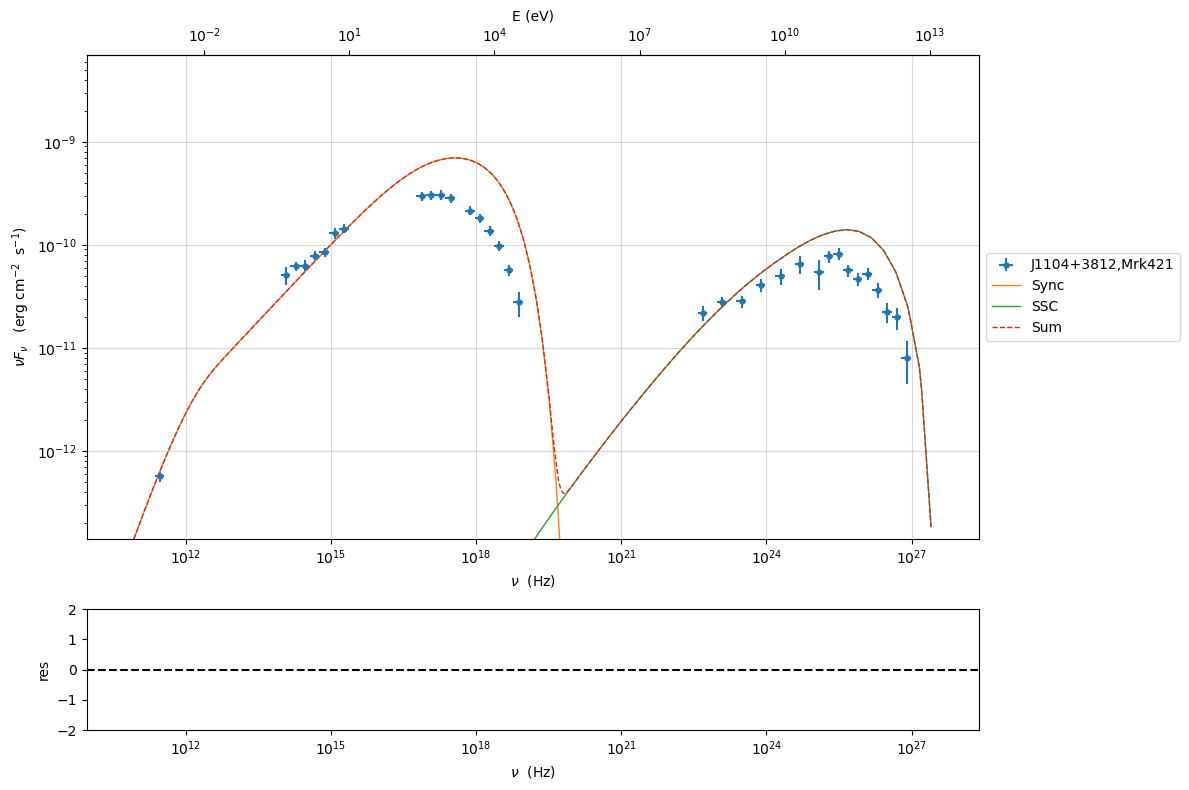

In [15]:
prefit_jet.eval()
prefit_jet.plot_model(sed_data=sed_data)

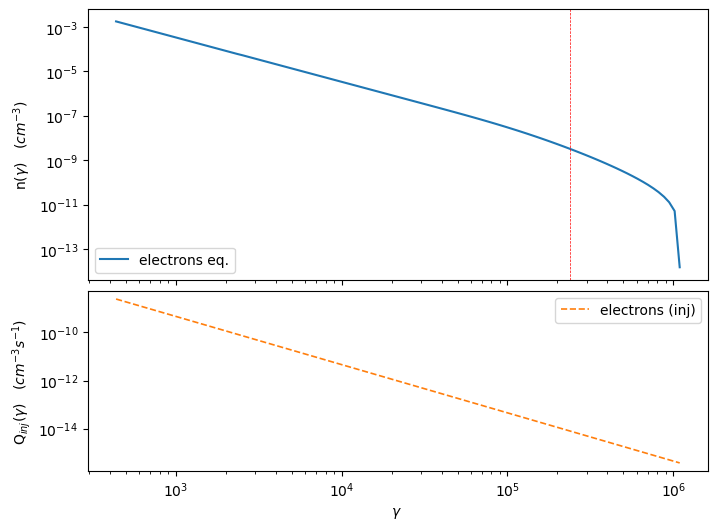

In [16]:
prefit_jet.emitters_distribution.plot()

In [17]:
prefit_jet.parameters

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
leptonic_eq,R,region_size,cm,2.219270e+16,1.000000e+03,1.000000e+30,False,False
leptonic_eq,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
leptonic_eq,B,magnetic_field,gauss,6.618390e-02,0.000000e+00,--,False,False
leptonic_eq,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
leptonic_eq,beam_obj,beaming,,2.500000e+01,1.000000e-04,--,False,False
leptonic_eq,z_cosm,redshift,,3.080000e-02,0.000000e+00,--,False,False
leptonic_eq,gmin,low-energy-cut-off,lorentz-factor*,4.103365e+02,1.000000e+00,1.000000e+09,False,False
leptonic_eq,gmax,high-energy-cut-off,lorentz-factor*,1.136207e+06,1.000000e+00,1.000000e+15,False,False
leptonic_eq,p,LE_spectral_slope,,2.000000e+00,-1.000000e+01,1.000000e+01,False,False
leptonic_eq,T_esc_e_primaries,escape_time,R / c,1.000000e+00,1.000000e+00,--,False,False


None

## Model fitting procedure

### Model fitting with Minuit

In [18]:
from jetset.minimizer import ModelMinimizer

from jetset.model_manager import  FitModel


We use the `prefit_jet`  model to build the `FitModel`

In [19]:
fit_model=FitModel( jet=prefit_jet, name='SSC-best-fit',template=None) 

In [20]:
fit_model.show_model_components()


--------------------------------------------------------------------------------
Composite model description
--------------------------------------------------------------------------------
name: SSC-best-fit  
type: composite_model  
components models:
 -model name: leptonic_eq model type: jet

--------------------------------------------------------------------------------


There is only one component, whit name `leptonic_eq`, that refers to the `prefit_jet` model component (renamed to `leptonic_eq`).

We now set the gamma grid size to 200, ad we set `composite_expr`, anyhow, since we have only one component this step could be skipped

In [21]:
fit_model.leptonic_eq.set_gamma_grid_size(200)
fit_model.composite_expr='leptonic_eq'

#### Freezeing parameters and setting fit_range intervals

In [22]:

fit_model.freeze('leptonic_eq','z_cosm')
fit_model.freeze('leptonic_eq','R_H')
fit_model.freeze('leptonic_eq','T_esc_e_primaries')

fit_model.leptonic_eq.parameters.R.fit_range=[10**15.5,10**17.5]
fit_model.leptonic_eq.parameters.beam_obj.fit_range=[5., 50.]
fit_model.leptonic_eq.parameters.gmax.fit_range=[1E5, 5E6]
fit_model.leptonic_eq.parameters.gmin.fit_range=[10, 1000]
fit_model.leptonic_eq.parameters.T_esc_e_primaries.val=1
fit_model.leptonic_eq.parameters.L_inj.fit_range=[1E38, 1E43]



In [23]:
fit_model.parameters

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
leptonic_eq,R,region_size,cm,2.219270e+16,1.000000e+03,1.000000e+30,False,False
leptonic_eq,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
leptonic_eq,B,magnetic_field,gauss,6.618390e-02,0.000000e+00,--,False,False
leptonic_eq,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
leptonic_eq,beam_obj,beaming,,2.500000e+01,1.000000e-04,--,False,False
leptonic_eq,z_cosm,redshift,,3.080000e-02,0.000000e+00,--,False,True
leptonic_eq,gmin,low-energy-cut-off,lorentz-factor*,4.103365e+02,1.000000e+00,1.000000e+09,False,False
leptonic_eq,gmax,high-energy-cut-off,lorentz-factor*,1.136207e+06,1.000000e+00,1.000000e+15,False,False
leptonic_eq,p,LE_spectral_slope,,2.000000e+00,-1.000000e+01,1.000000e+01,False,False
leptonic_eq,T_esc_e_primaries,escape_time,R / c,1.000000e+00,1.000000e+00,--,False,True


None

#### Building the ModelMinimizer object

In [24]:
model_minimizer_minuit=ModelMinimizer('minuit')
best_fit_minuit=model_minimizer_minuit.fit(fit_model,
                                           sed_data,
                                           1E11,
                                           1E29,
                                           fitname='SSC-best-fit-minuit',
                                           max_ev=10000,
                                           repeat=1)

filtering data in fit range = [1.000000e+11,1.000000e+29]
data length 34

*** start fit process ***
----- 


0it [00:00, ?it/s]

- best chisq=4.02541e+01

-------------------------------------------------------------------------
Fit report

Model: SSC-best-fit-minuit


model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
leptonic_eq,R,region_size,cm,2.293605e+16,1.000000e+03,1.000000e+30,False,False
leptonic_eq,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
leptonic_eq,B,magnetic_field,gauss,9.999970e-02,0.000000e+00,--,False,False
leptonic_eq,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
leptonic_eq,beam_obj,beaming,,1.988105e+01,1.000000e-04,--,False,False
leptonic_eq,z_cosm,redshift,,3.080000e-02,0.000000e+00,--,False,True
leptonic_eq,gmin,low-energy-cut-off,lorentz-factor*,4.820682e+02,1.000000e+00,1.000000e+09,False,False
leptonic_eq,gmax,high-energy-cut-off,lorentz-factor*,7.989524e+05,1.000000e+00,1.000000e+15,False,False
leptonic_eq,p,LE_spectral_slope,,2.099530e+00,-1.000000e+01,1.000000e+01,False,False
leptonic_eq,T_esc_e_primaries,escape_time,R / c,1.000000e+00,1.000000e+00,--,False,True



converged=True
calls=3001
mesg=


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 40.25                      │             Nfcn = 3001              │
│ EDM = 28.2 (Goal: 0.0002)        │           time = 23.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   ABOVE EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │        Covariance APPROXIMATE        │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ par_0 │  22.9e15  │  1.9e15   │            │            │3.16228e+15│3.16228e+17│       │
│ 1 │ par_1 │   0.100   │   0.005   │            │            │    0    │         │       │
│ 2 │ par_2 │   19.9    │    0.4    │            │            │    5    │   50    │       │
│ 3 │ par_3 │ 482.0682  │  0.0009   │            │            │   10    │  1000   │       │
│ 4 │ par_4 │  0.799e6  │  0.020e6  │            │            │ 100000  │  5e+06  │       │
│ 5 │ par_5 │   2.100   │   0.013   │            │            │   -10   │   10    │       │
│ 6 │ par_6 │ 0.159e42  │ 0.010e42  │            │            │  1e+38  │  1e+43  │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘

dof=27
chisq=40.254144, chisq/red=1.490894 null hypothesis sig=0.048498

best fit pars


model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
leptonic_eq,R,2.293605e+16,2.293605e+16,1.877852e+15,--,2.219270e+16,3.162278e+15,3.162278e+17,False
leptonic_eq,R_H,1.000000e+17,--,--,--,1.000000e+17,0.000000e+00,--,True
leptonic_eq,B,9.999970e-02,9.999970e-02,4.621741e-03,--,6.618390e-02,0.000000e+00,--,False
leptonic_eq,NH_cold_to_rel_e,1.000000e+00,--,--,--,1.000000e+00,0.000000e+00,--,True
leptonic_eq,beam_obj,1.988105e+01,1.988105e+01,4.479375e-01,--,2.500000e+01,5.000000e+00,5.000000e+01,False
leptonic_eq,z_cosm,3.080000e-02,--,--,--,3.080000e-02,0.000000e+00,--,True
leptonic_eq,gmin,4.820682e+02,4.820682e+02,8.911954e-04,--,4.103365e+02,1.000000e+01,1.000000e+03,False
leptonic_eq,gmax,7.989524e+05,7.989524e+05,2.016861e+04,--,1.136207e+06,1.000000e+05,5.000000e+06,False
leptonic_eq,p,2.099530e+00,2.099530e+00,1.336951e-02,--,2.000000e+00,-1.000000e+01,1.000000e+01,False
leptonic_eq,T_esc_e_primaries,1.000000e+00,--,--,--,1.000000e+00,1.000000e+00,--,True


-------------------------------------------------------------------------




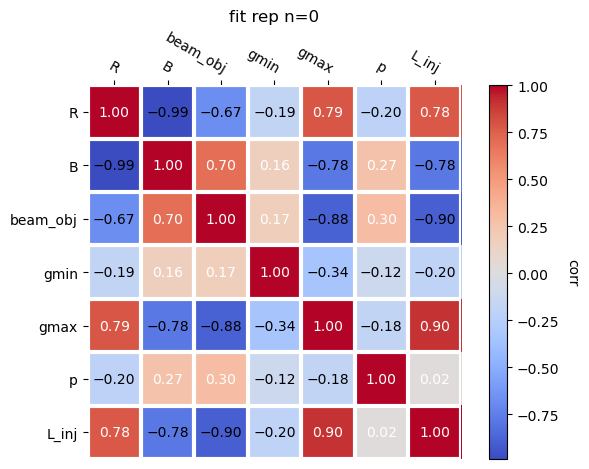

In [25]:
p=model_minimizer_minuit.plot_corr_matrix()

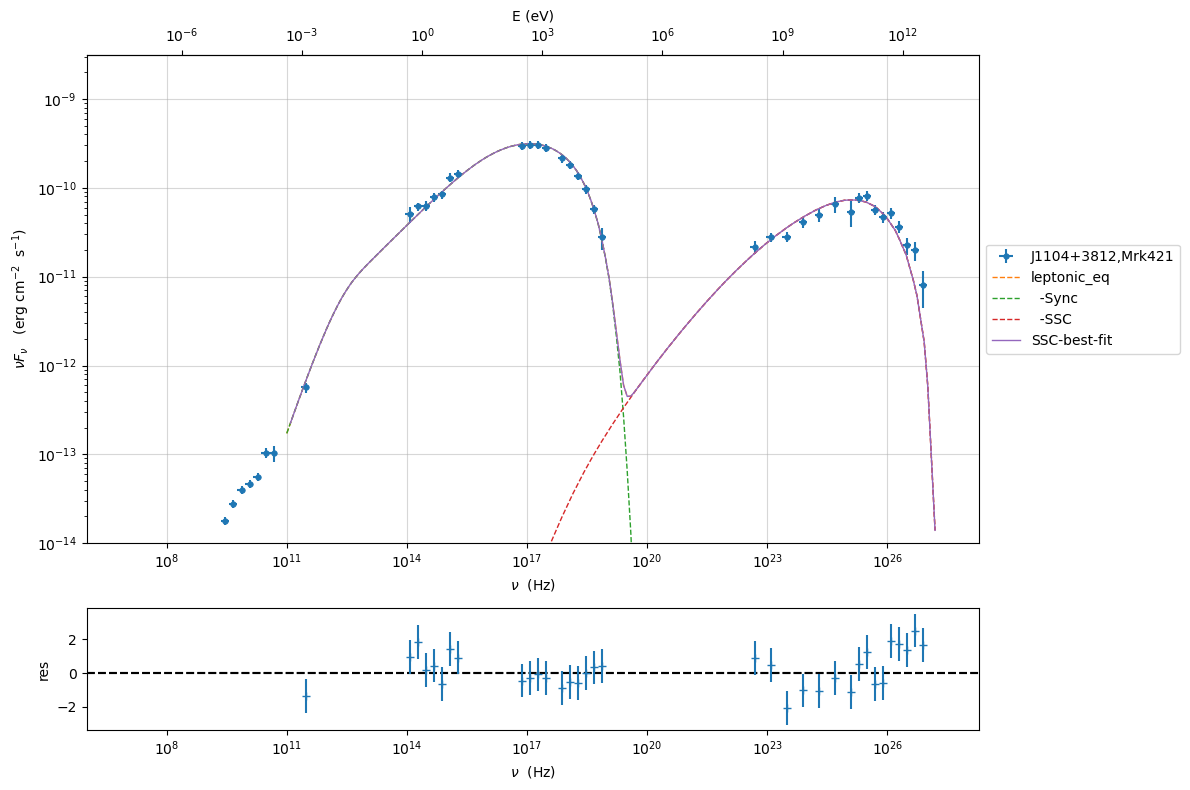

In [26]:
%matplotlib inline
fit_model.eval()
p2=fit_model.plot_model(sed_data=sed_data)
p2.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

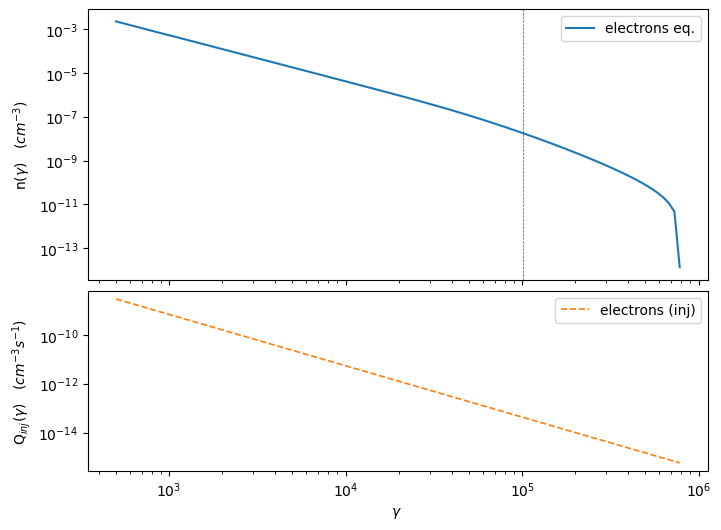

In [27]:
fit_model.leptonic_eq.emitters_distribution.plot()


#### saving fit model, model minimizer

In [28]:
best_fit_minuit.save_report('SSC-best-fit-minuit.pkl')
model_minimizer_minuit.save_model('model_minimizer_minuit.pkl')
fit_model.save_model('fit_model_minuit.pkl')

## MCMC sampling

### creating and setting the sampler

In [29]:
from jetset.data_loader import ObsData

sed_data=ObsData.load('Mrk_401.pkl')

In [30]:
from jetset.mcmc import McmcSampler
from jetset.minimizer import ModelMinimizer


In [31]:
model_minimizer = ModelMinimizer.load_model('model_minimizer_minuit.pkl')

mcmc=McmcSampler(model_minimizer)


You can inspect the mcmc parameters using:

In [32]:
mcmc.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str11,str17,float64,bool,float64,float64,float64,float64,float64,float64,bool
leptonic_eq,gmin,4.820682e+02,False,4.820682e+02,--,--,--,1.000000e+01,1.000000e+03,False
leptonic_eq,gmax,7.989524e+05,False,7.989524e+05,--,--,--,1.000000e+05,5.000000e+06,False
leptonic_eq,p,2.099530e+00,False,2.099530e+00,--,--,--,-1.000000e+01,1.000000e+01,False
leptonic_eq,L_inj,1.594854e+41,False,1.594854e+41,--,--,--,1.000000e+38,1.000000e+43,False
leptonic_eq,R,2.293605e+16,False,2.293605e+16,--,--,--,3.162278e+15,3.162278e+17,False
leptonic_eq,B,9.999970e-02,False,9.999970e-02,--,--,--,0.000000e+00,--,False
leptonic_eq,beam_obj,1.988105e+01,False,1.988105e+01,--,--,--,5.000000e+00,5.000000e+01,False
leptonic_eq,T_esc_e_primaries,1.000000e+00,False,--,--,--,--,1.000000e+00,--,True
leptonic_eq,R_H,1.000000e+17,False,--,--,--,--,0.000000e+00,--,True


If you want to exclude or include parameters from the samplers just freeze/free them 

In [33]:
mcmc.model.leptonic_eq.parameters.T_esc_e_primaries.frozen=True


You can set different bounds for all the free parameters with the instruction below. In case you want to preserve the `fit_range` defined in the frequentist minimizer you can pass `preserve_fit_range=True`

In [34]:
mcmc.set_bounds(bound=5.0,bound_rel=True)

par: gmin  ref value:  482.06815780972534  mcmc bounds: [10, 1000]
par: gmax  ref value:  798952.4062170115  mcmc bounds: [100000.0, np.float64(4793714.437302069)]
par: p  ref value:  2.099529853039601  mcmc bounds: [np.float64(-8.398119412158405), 10]
par: L_inj  ref value:  1.5948541733480243e+41  mcmc bounds: [1e+38, np.float64(9.569125040088146e+41)]
par: R  ref value:  2.29360478053214e+16  mcmc bounds: [3162277660168379.5, np.float64(1.3761628683192842e+17)]
par: B  ref value:  0.0999996999824615  mcmc bounds: [0, np.float64(0.599998199894769)]
par: beam_obj  ref value:  19.881048512008306  mcmc bounds: [5.0, 50.0]


Or, you can set per-parameter bounds as follows, passing the actual bound for each parameter.

In [35]:
mcmc.set_bounds(comp_name='leptonic_eq',par_name='L_inj',par_bounds=[1E37,1E43])
mcmc.set_bounds(comp_name='leptonic_eq',par_name='gmin',par_bounds=[10,2000])



par: L_inj  ref value:  1.5948541733480243e+41  mcmc bounds: [1e+38, 1e+43]
par: gmin  ref value:  482.06815780972534  mcmc bounds: [10, 1000]


In [36]:
mcmc.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str11,str17,float64,bool,float64,float64,float64,float64,float64,float64,bool
leptonic_eq,gmin,4.820682e+02,False,4.820682e+02,--,--,--,1.000000e+01,1.000000e+03,False
leptonic_eq,gmax,7.989524e+05,False,7.989524e+05,--,--,--,1.000000e+05,4.793714e+06,False
leptonic_eq,p,2.099530e+00,False,2.099530e+00,--,--,--,-8.398119e+00,1.000000e+01,False
leptonic_eq,L_inj,1.594854e+41,False,1.594854e+41,--,--,--,1.000000e+38,1.000000e+43,False
leptonic_eq,R,2.293605e+16,False,2.293605e+16,--,--,--,3.162278e+15,1.376163e+17,False
leptonic_eq,B,9.999970e-02,False,9.999970e-02,--,--,--,0.000000e+00,5.999982e-01,False
leptonic_eq,beam_obj,1.988105e+01,False,1.988105e+01,--,--,--,5.000000e+00,5.000000e+01,False
leptonic_eq,T_esc_e_primaries,1.000000e+00,False,--,--,--,--,1.000000e+00,--,True
leptonic_eq,R_H,1.000000e+17,False,--,--,--,--,0.000000e+00,--,True


In [37]:
mcmc.run_sampler(nwalkers=30, burnin=50,steps=500,progress='notebook')


mcmc run starting



  0%|          | 0/500 [00:00<?, ?it/s]

mcmc run done, with 1 threads took 121.55 seconds
----------------------------
MCMC best fit solution
comp: leptonic_eq par: gmin  mcmc best fit val: 938.06939050328 quantiles(0.16,0.5,0.84): [549.87841228 738.1979352  873.30583605] 
comp: leptonic_eq par: gmax  mcmc best fit val: 1096972.3818084246 quantiles(0.16,0.5,0.84): [ 825321.65909323  955360.3692434  1102716.46439814] 
comp: leptonic_eq par: p  mcmc best fit val: 2.239008026417144 quantiles(0.16,0.5,0.84): [2.10338086 2.17333251 2.25380331] 
comp: leptonic_eq par: L_inj  mcmc best fit val: 2.0305541578887544e+41 quantiles(0.16,0.5,0.84): [1.44445183e+41 1.78017869e+41 2.40955195e+41] 
comp: leptonic_eq par: R  mcmc best fit val: 3.796263778809784e+16 quantiles(0.16,0.5,0.84): [2.30660820e+16 2.98273288e+16 4.29937507e+16] 
comp: leptonic_eq par: B  mcmc best fit val: 0.05165970111094412 quantiles(0.16,0.5,0.84): [0.05231904 0.06454995 0.09123121] 
comp: leptonic_eq par: beam_obj  mcmc best fit val: 21.28267416705294 quantiles(

Showing the MCMC parameters. Now MCMC bestfit values are updated to the best-fit MCMC solution


In [38]:
mcmc.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str11,str17,float64,bool,float64,float64,float64,float64,float64,float64,bool
leptonic_eq,gmin,9.380694e+02,False,9.380694e+02,5.498784e+02,7.381979e+02,8.733058e+02,1.000000e+01,1.000000e+03,False
leptonic_eq,gmax,1.096972e+06,False,1.096972e+06,8.253217e+05,9.553604e+05,1.102716e+06,1.000000e+05,4.793714e+06,False
leptonic_eq,p,2.239008e+00,False,2.239008e+00,2.103381e+00,2.173333e+00,2.253803e+00,-8.398119e+00,1.000000e+01,False
leptonic_eq,L_inj,2.030554e+41,False,2.030554e+41,1.444452e+41,1.780179e+41,2.409552e+41,1.000000e+38,1.000000e+43,False
leptonic_eq,R,3.796264e+16,False,3.796264e+16,2.306608e+16,2.982733e+16,4.299375e+16,3.162278e+15,1.376163e+17,False
leptonic_eq,B,5.165970e-02,False,5.165970e-02,5.231904e-02,6.454995e-02,9.123121e-02,0.000000e+00,5.999982e-01,False
leptonic_eq,beam_obj,2.128267e+01,False,2.128267e+01,1.851374e+01,2.043306e+01,2.316419e+01,5.000000e+00,5.000000e+01,False
leptonic_eq,T_esc_e_primaries,1.000000e+00,False,--,--,--,--,1.000000e+00,--,True
leptonic_eq,R_H,1.000000e+17,False,--,--,--,--,0.000000e+00,--,True


### post-run tuning of the burnin
We plot the chains, before and after, tuning the burnin (using autocorrelation time of emcee).

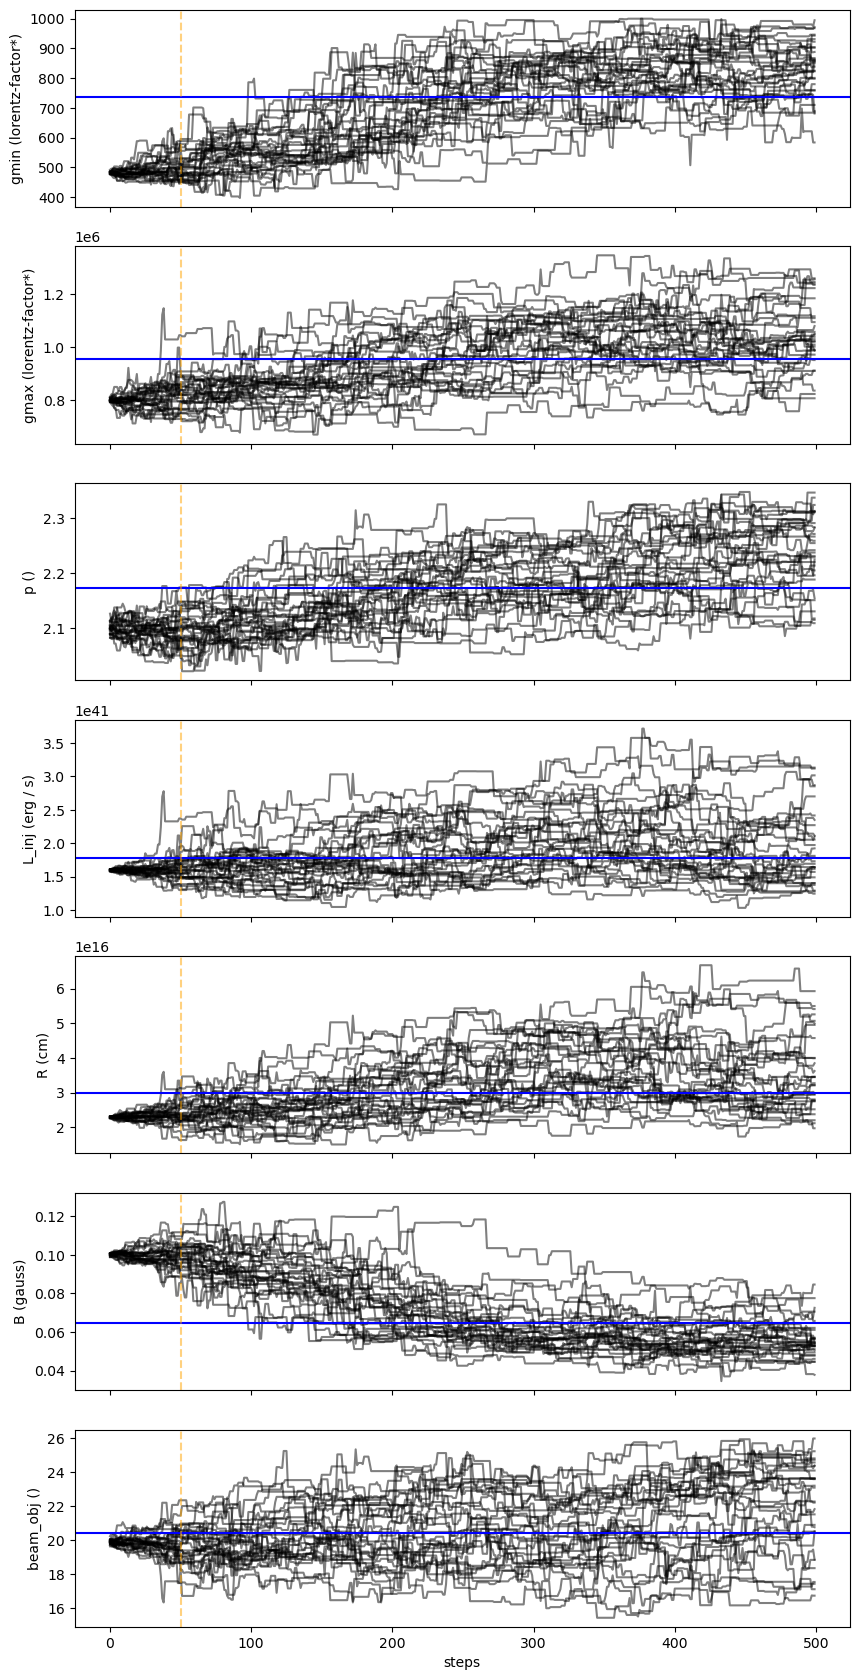

In [39]:
p=mcmc.plot_chain()

----------------------------
MCMC best fit solution
comp: leptonic_eq par: gmin  mcmc best fit val: 938.06939050328 quantiles(0.16,0.5,0.84): [615.79237641 776.23148514 887.62963902] 
comp: leptonic_eq par: gmax  mcmc best fit val: 1096972.3818084246 quantiles(0.16,0.5,0.84): [ 853194.1715297   989105.17631699 1115716.11258555] 
comp: leptonic_eq par: p  mcmc best fit val: 2.239008026417144 quantiles(0.16,0.5,0.84): [2.12335832 2.18748821 2.26404793] 
comp: leptonic_eq par: L_inj  mcmc best fit val: 2.0305541578887544e+41 quantiles(0.16,0.5,0.84): [1.46304671e+41 1.85210419e+41 2.47911716e+41] 
comp: leptonic_eq par: R  mcmc best fit val: 3.796263778809784e+16 quantiles(0.16,0.5,0.84): [2.44386205e+16 3.22514170e+16 4.47277965e+16] 
comp: leptonic_eq par: B  mcmc best fit val: 0.05165970111094412 quantiles(0.16,0.5,0.84): [0.05129014 0.0607574  0.08044518] 
comp: leptonic_eq par: beam_obj  mcmc best fit val: 21.28267416705294 quantiles(0.16,0.5,0.84): [18.45888288 20.77343687 23.394241

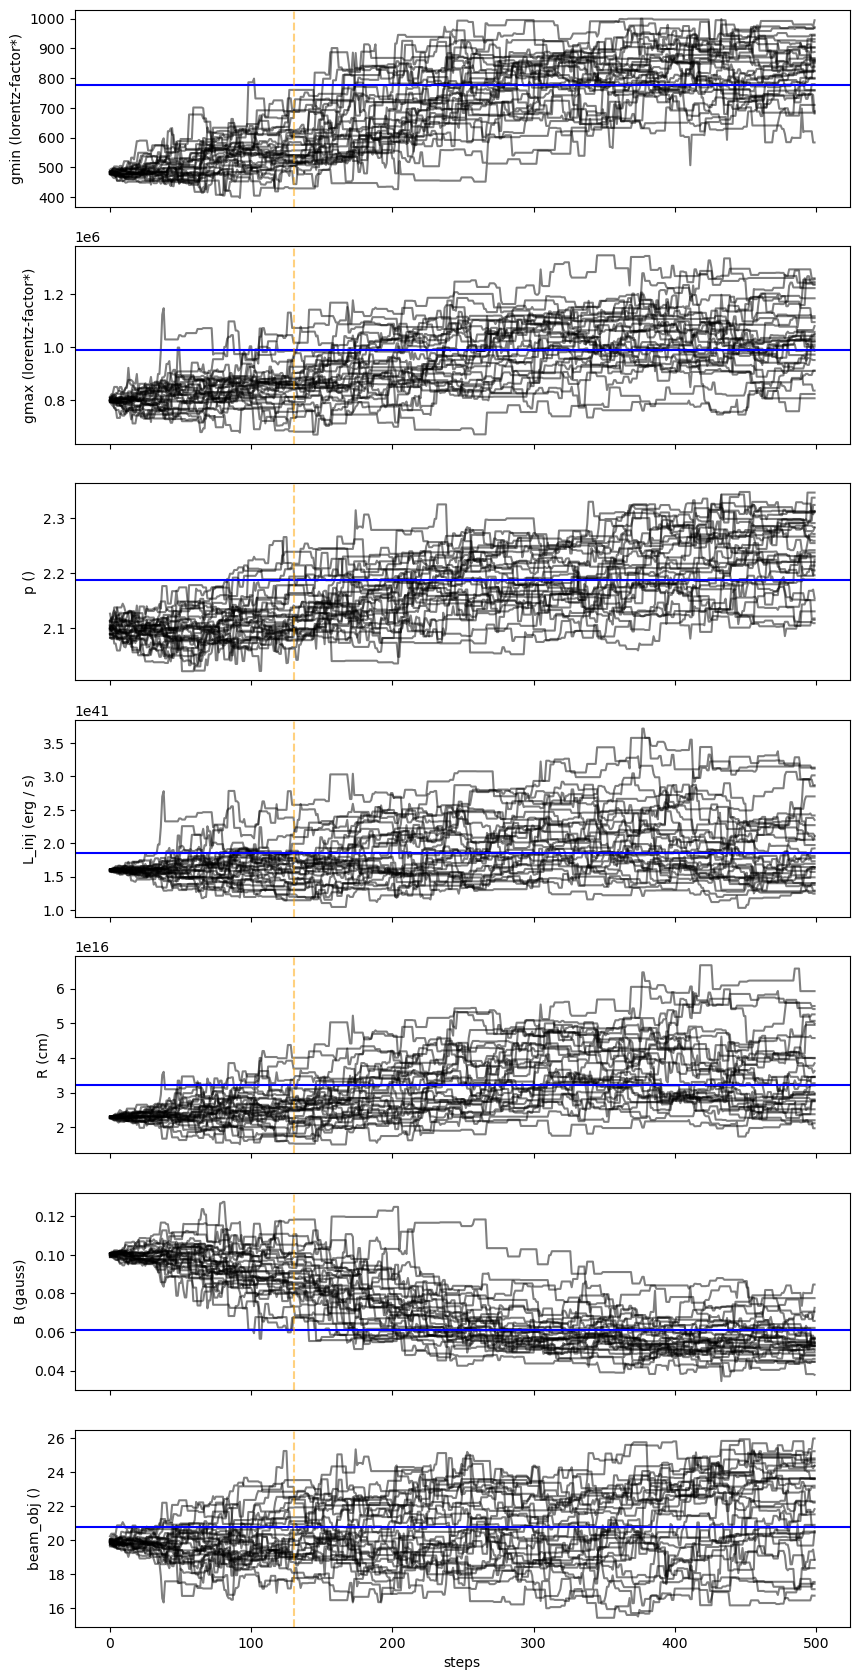

In [40]:
mcmc.tune_burnin(tau_coeff=2)
p=mcmc.plot_chain()

The updated burnin value has increased compared to the initial one, now the chain samples a parameter space closer to the convergence.

### plotting the posterior corner plot

To have a better rendering on the scatter plot, we redefine the plot labels

In [41]:
mcmc.set_plot_label('L_inj',r'$L_{inj}$',comp_name='leptonic_eq')
mcmc.set_plot_label('B',r'$B$',comp_name='leptonic_eq')
mcmc.set_plot_label('gmin',r'$\gamma_{\rm min}$',comp_name='leptonic_eq')
mcmc.set_plot_label('gmax',r'$\gamma_{\rm max}$',comp_name='leptonic_eq')
mcmc.set_plot_label('beam_obj',r'$\delta$',comp_name='leptonic_eq')
mcmc.set_plot_label('p',r'$p$',comp_name='leptonic_eq')


the code below lets you tuning the output

1) mpl.rcParams['figure.dpi'] if you increase it you get a better definition
2) title_fmt=".2E" this is the format for python, 2 significant digits, scientific notation
3) title_kwargs=dict(fontsize=12) you can change the fontsize

Per-component corner plot

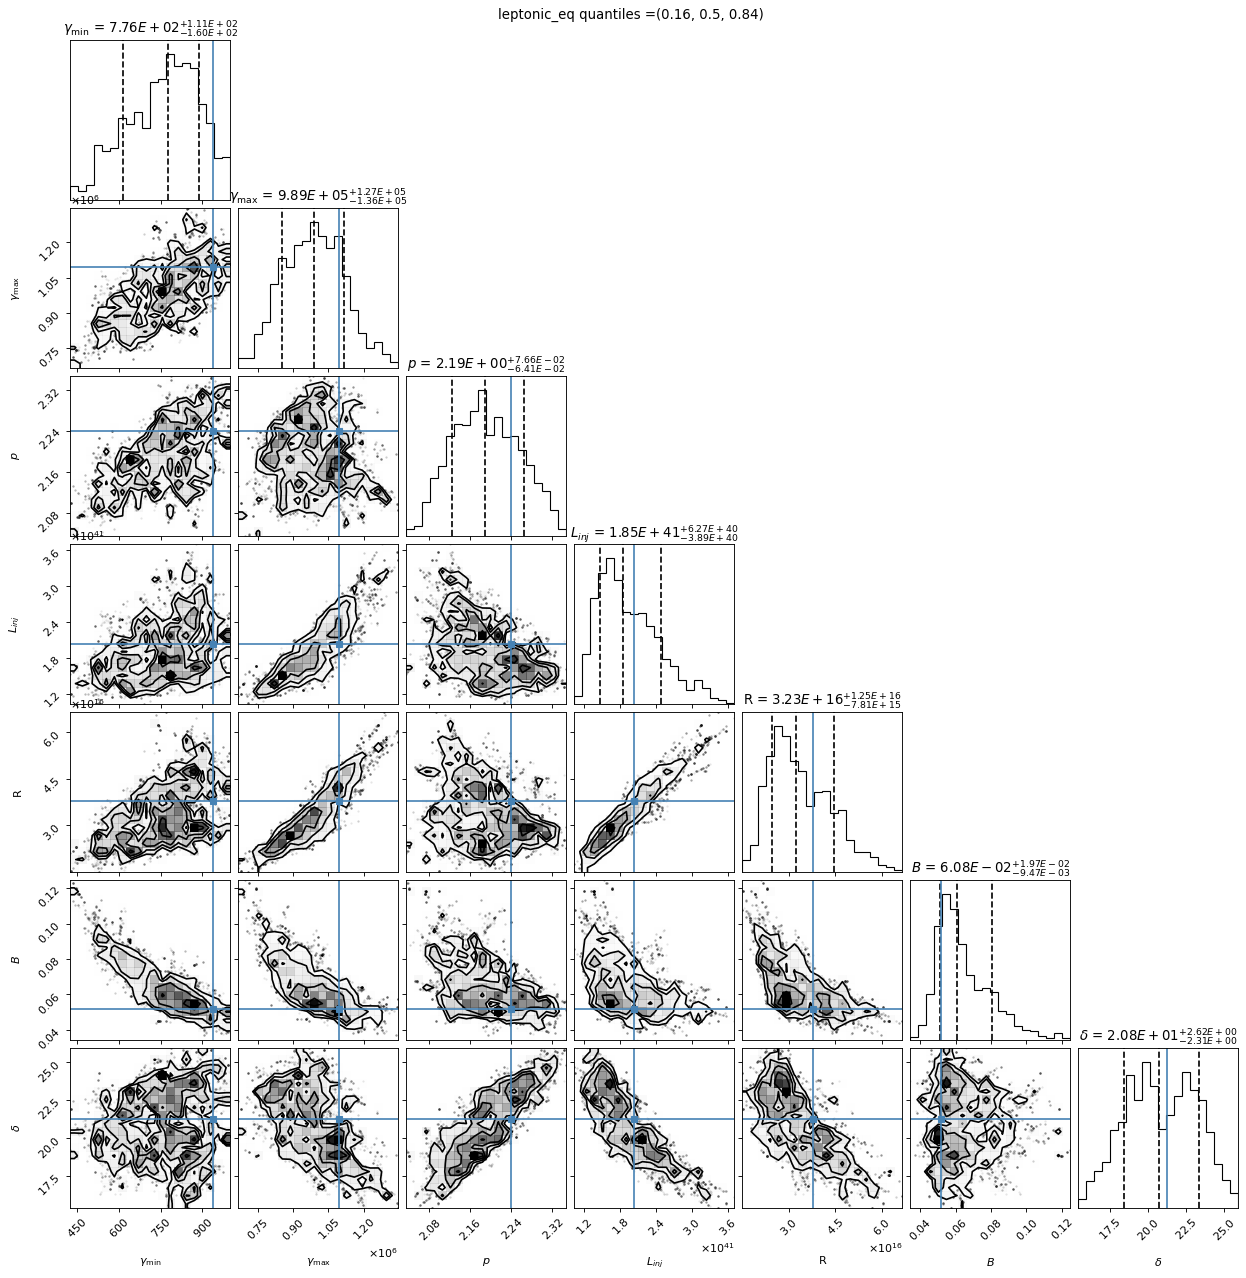

In [42]:
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 80
f=mcmc.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True)

In [43]:
print(mcmc.acceptance_fraction)

0.2702


### plotting the model

To plot the sampled model range against the input mcmc best-fit model

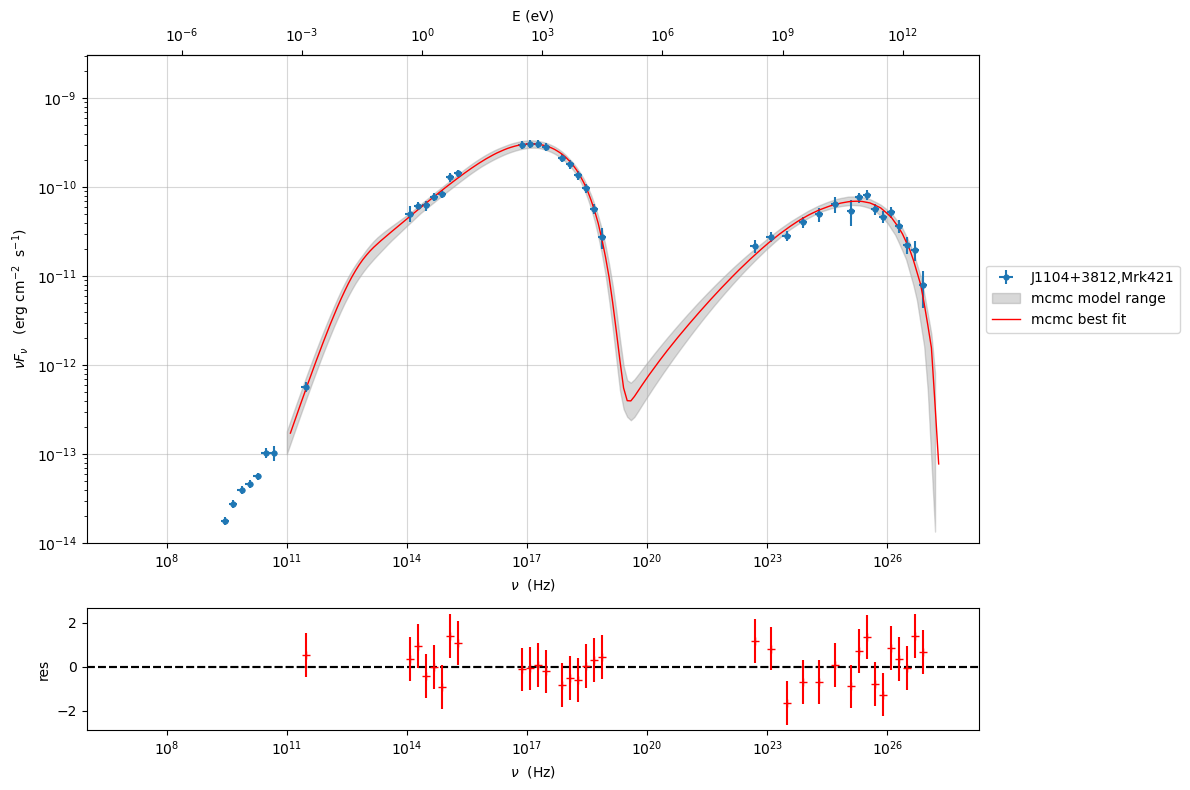

In [44]:

from jetset.data_loader import ObsData
sed_data=ObsData.load('Mrk_401.pkl')
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,size=100)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

To plot the mcmc best-fit model providing quantiles. The size parameter defines the number of samples to use to extract the quantiles. I am using a size equal to the number of steps

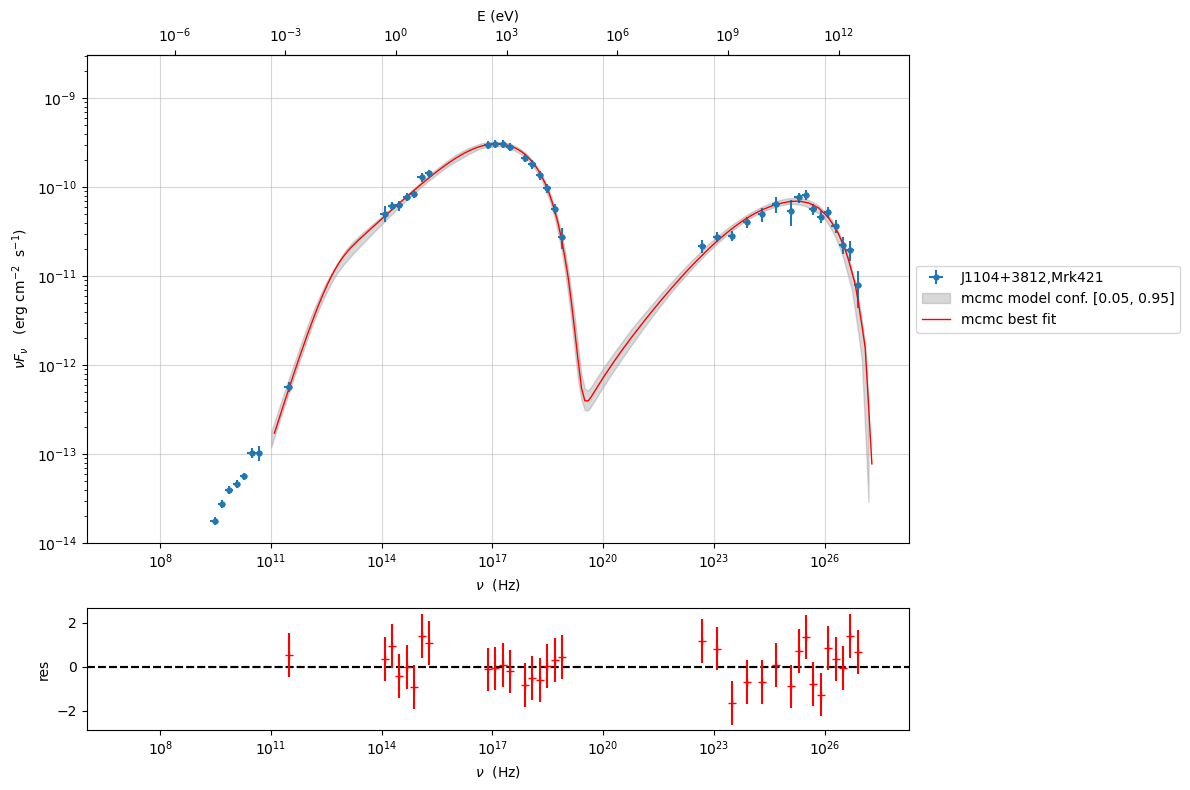

In [45]:
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,size=100,quantiles=[0.05,0.95])
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

If you want to plot also the model components, pass the argument `plot_components=True`

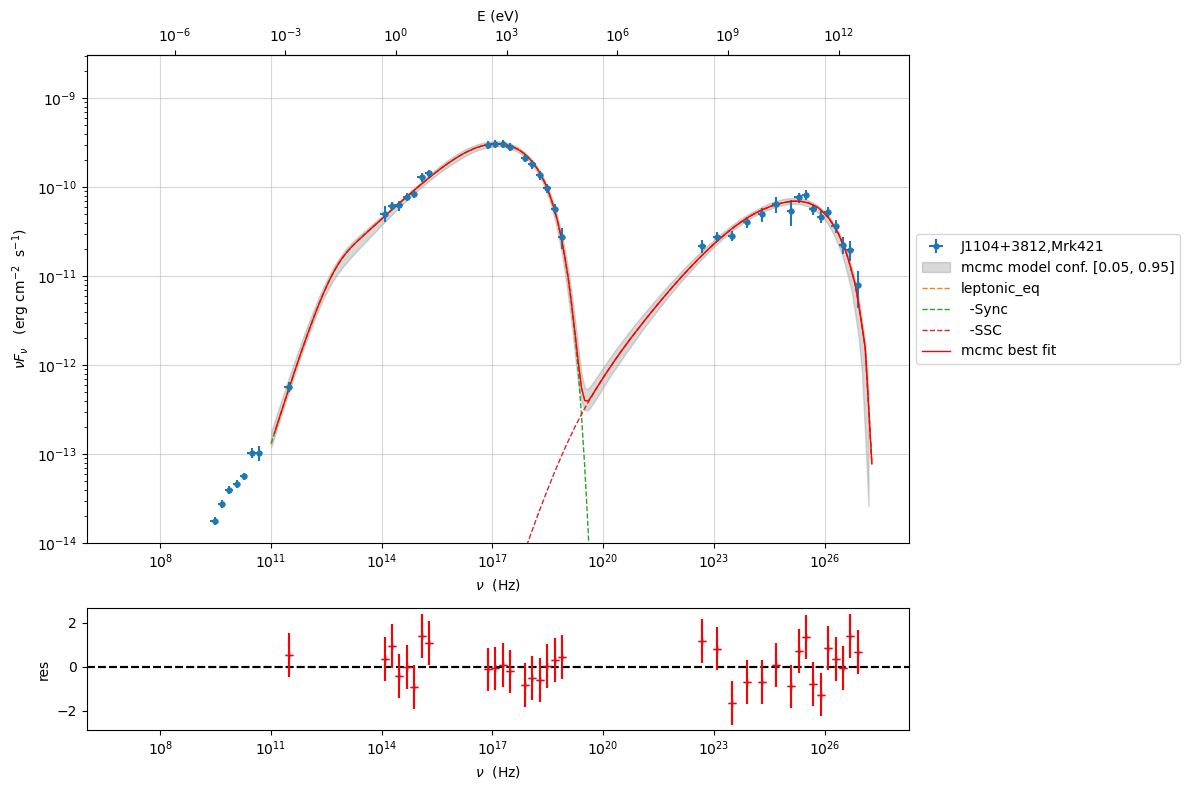

In [46]:
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,size=500,quantiles=[0.05,0.95],plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

To plot the frequentist  best-fit  model range,p roviding quantiles, provide (``plot_mcmc_best_fit_model=False``)

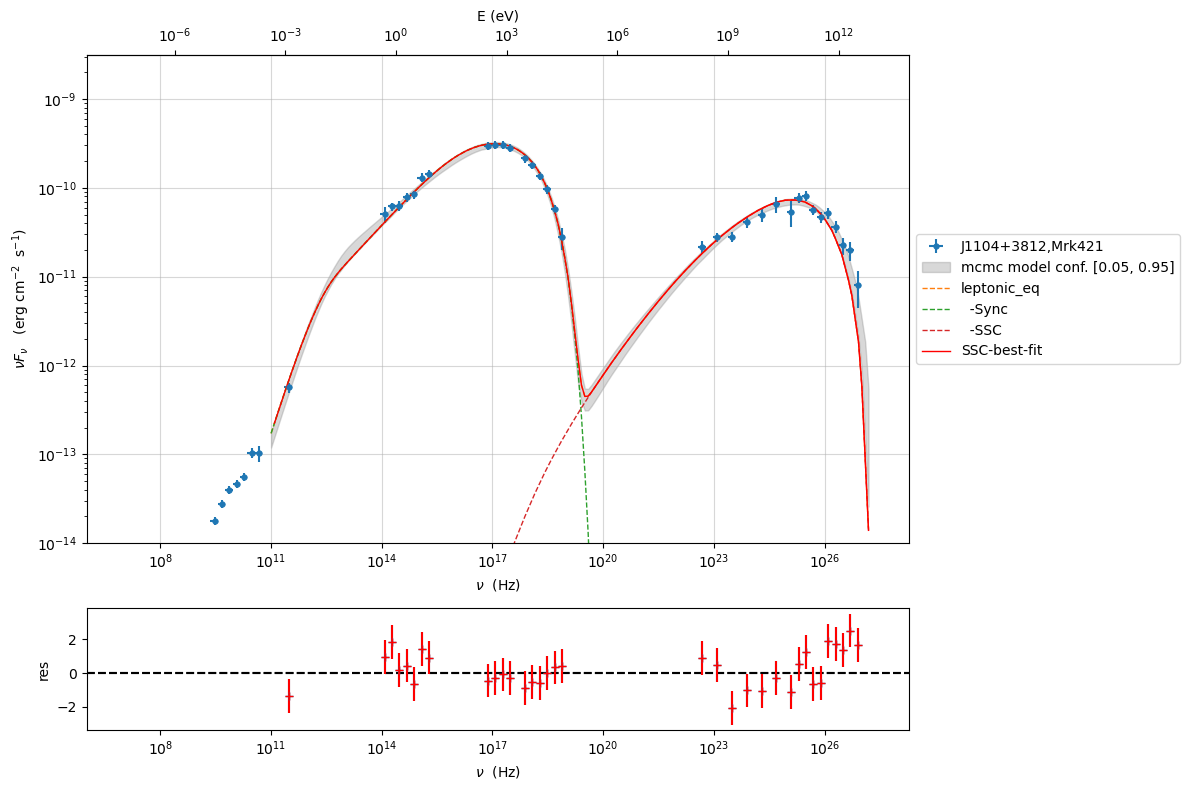

In [47]:
mpl.rcParams['figure.dpi'] = 100
p=mcmc.plot_model(sed_data=sed_data,size=500,quantiles=[0.05,0.95], plot_mcmc_best_fit_model=False,plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

### plotting chains and individual posteriors

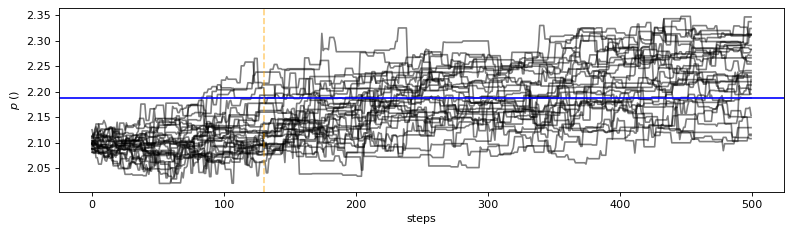

In [48]:
import matplotlib.pylab as plt

mpl.rcParams['figure.dpi'] = 80
f=mcmc.plot_chain(par_name='p',log_plot=False)
plt.tight_layout()

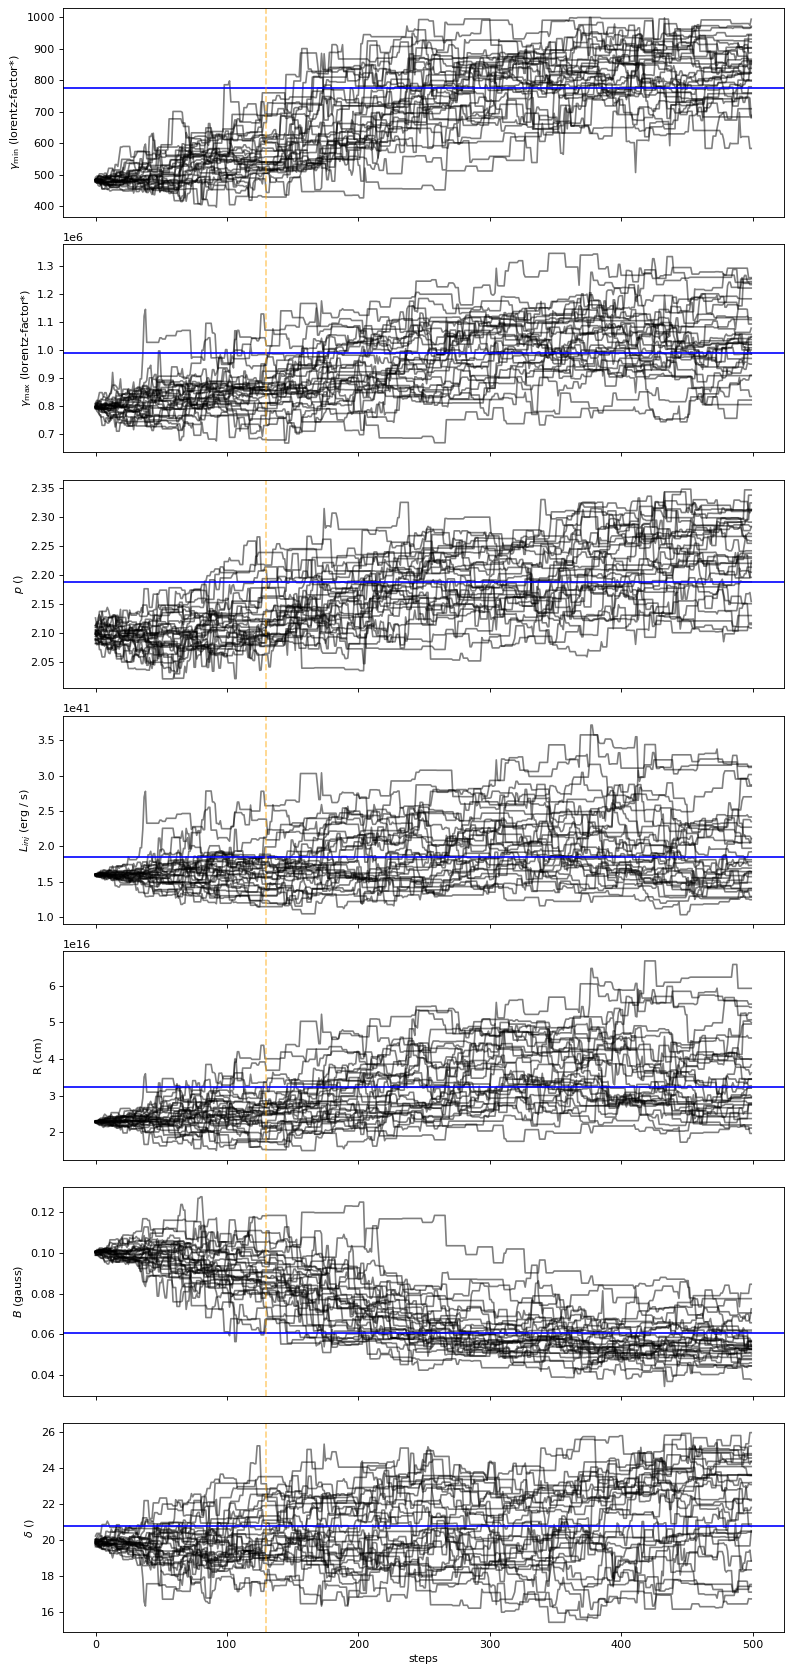

In [49]:
mpl.rcParams['figure.dpi'] = 80
f=mcmc.plot_chain(log_plot=False)
plt.tight_layout()

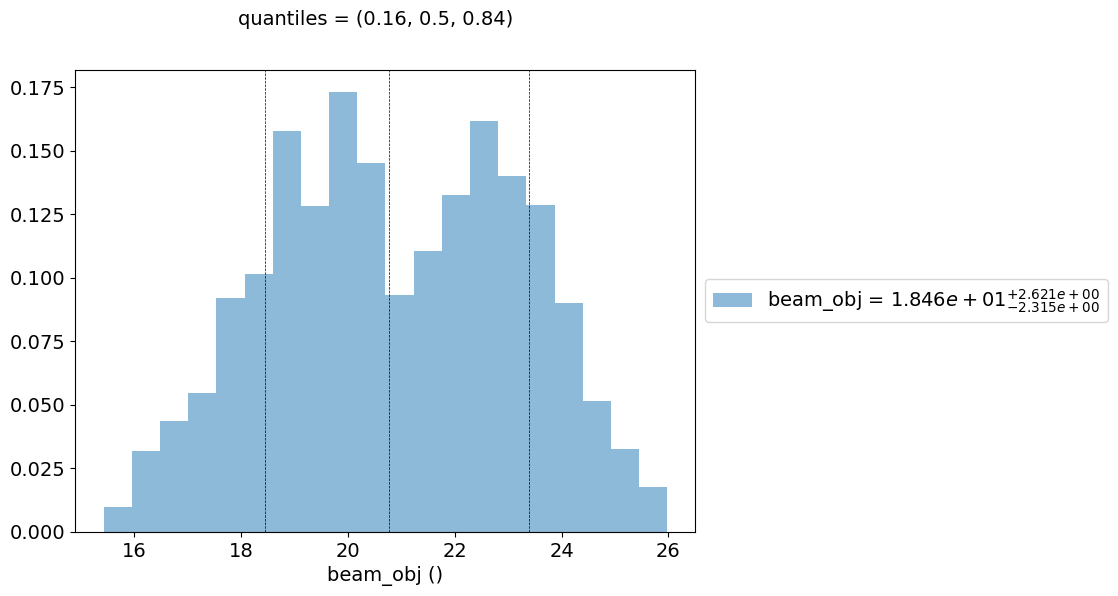

In [50]:

f=mcmc.plot_par('beam_obj',figsize=(8,6))
mpl.rcParams['figure.dpi'] = 80

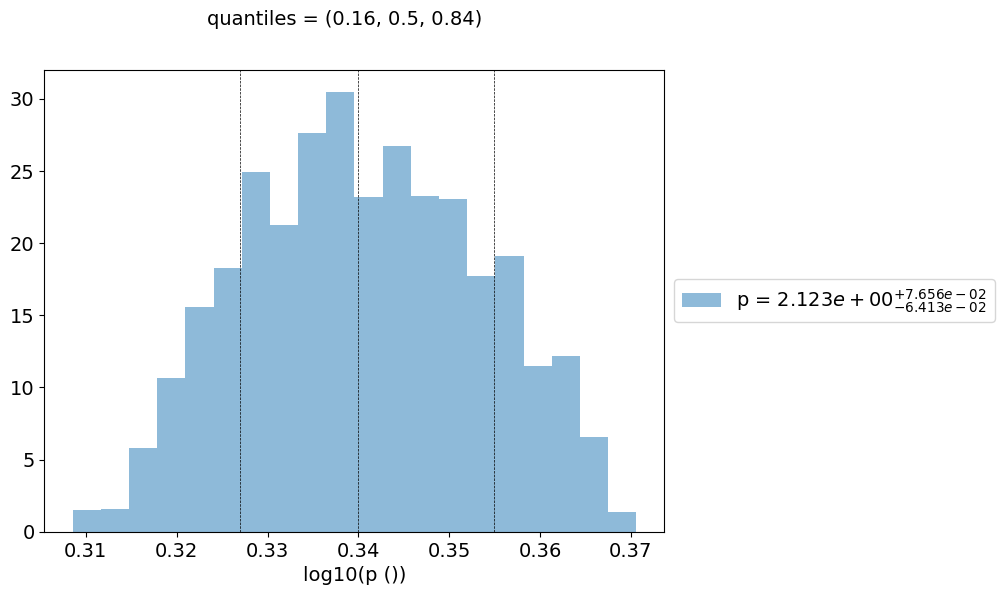

In [51]:
mpl.rcParams['figure.dpi'] = 80
f=mcmc.plot_par('p',log_plot=True,figsize=(8,6))

## Save and reuse MCMC

In [52]:
mcmc.save('mcmc_sampler.pkl')

In [53]:
from jetset.mcmc import McmcSampler
from jetset.data_loader import ObsData

sed_data=ObsData.load('Mrk_401.pkl')
ms=McmcSampler.load('mcmc_sampler.pkl')

import matplotlib as mpl


In [54]:
ms.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str11,str17,float64,bool,float64,float64,float64,float64,float64,float64,bool
leptonic_eq,gmin,9.380694e+02,False,9.380694e+02,6.157924e+02,7.762315e+02,8.876296e+02,1.000000e+01,1.000000e+03,False
leptonic_eq,gmax,1.096972e+06,False,1.096972e+06,8.531942e+05,9.891052e+05,1.115716e+06,1.000000e+05,4.793714e+06,False
leptonic_eq,p,2.239008e+00,False,2.239008e+00,2.123358e+00,2.187488e+00,2.264048e+00,-8.398119e+00,1.000000e+01,False
leptonic_eq,L_inj,2.030554e+41,False,2.030554e+41,1.463047e+41,1.852104e+41,2.479117e+41,1.000000e+38,1.000000e+43,False
leptonic_eq,R,3.796264e+16,False,3.796264e+16,2.443862e+16,3.225142e+16,4.472780e+16,3.162278e+15,1.376163e+17,False
leptonic_eq,B,5.165970e-02,False,5.165970e-02,5.129014e-02,6.075740e-02,8.044518e-02,0.000000e+00,5.999982e-01,False
leptonic_eq,beam_obj,2.128267e+01,False,2.128267e+01,1.845888e+01,2.077344e+01,2.339424e+01,5.000000e+00,5.000000e+01,False
leptonic_eq,T_esc_e_primaries,1.000000e+00,False,--,--,--,--,1.000000e+00,--,True
leptonic_eq,R_H,1.000000e+17,False,--,--,--,--,0.000000e+00,--,True


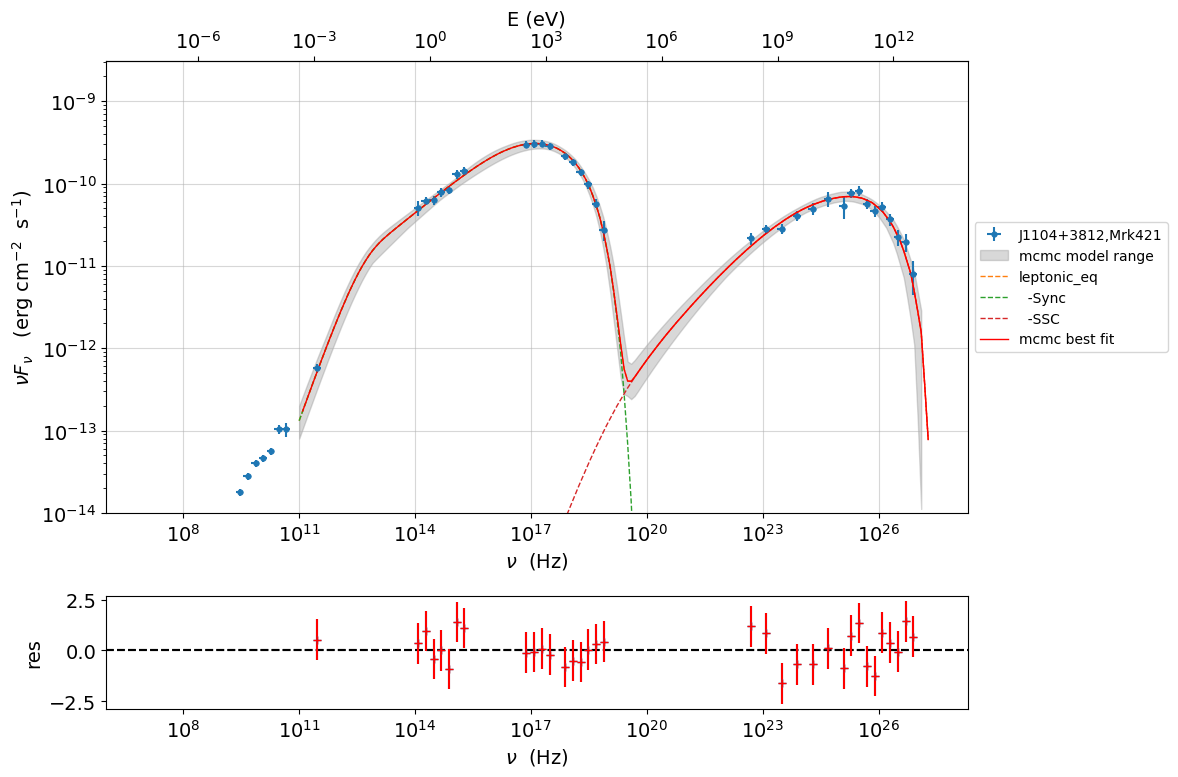

In [55]:
mpl.rcParams['figure.dpi'] = 80
p=ms.plot_model(sed_data=sed_data,size=500,plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

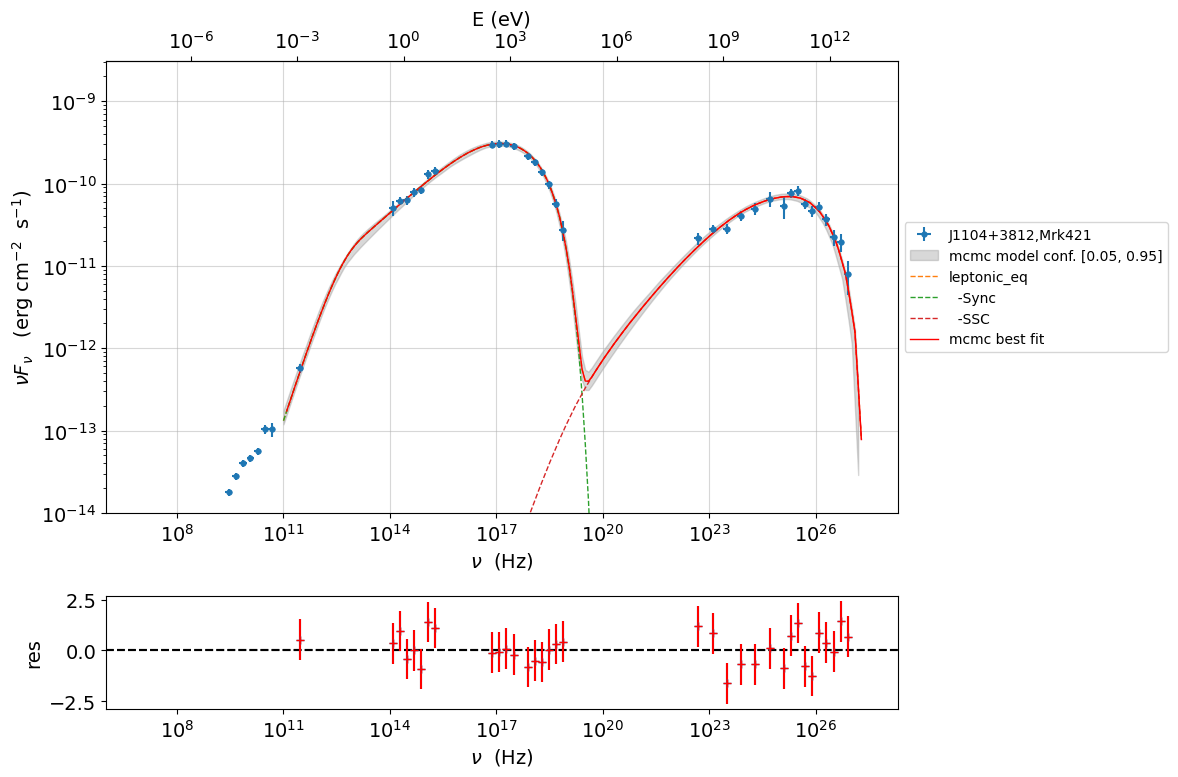

In [56]:
mpl.rcParams['figure.dpi'] = 80
p=ms.plot_model(sed_data=sed_data,size=100,quantiles=[0.05,0.95],plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

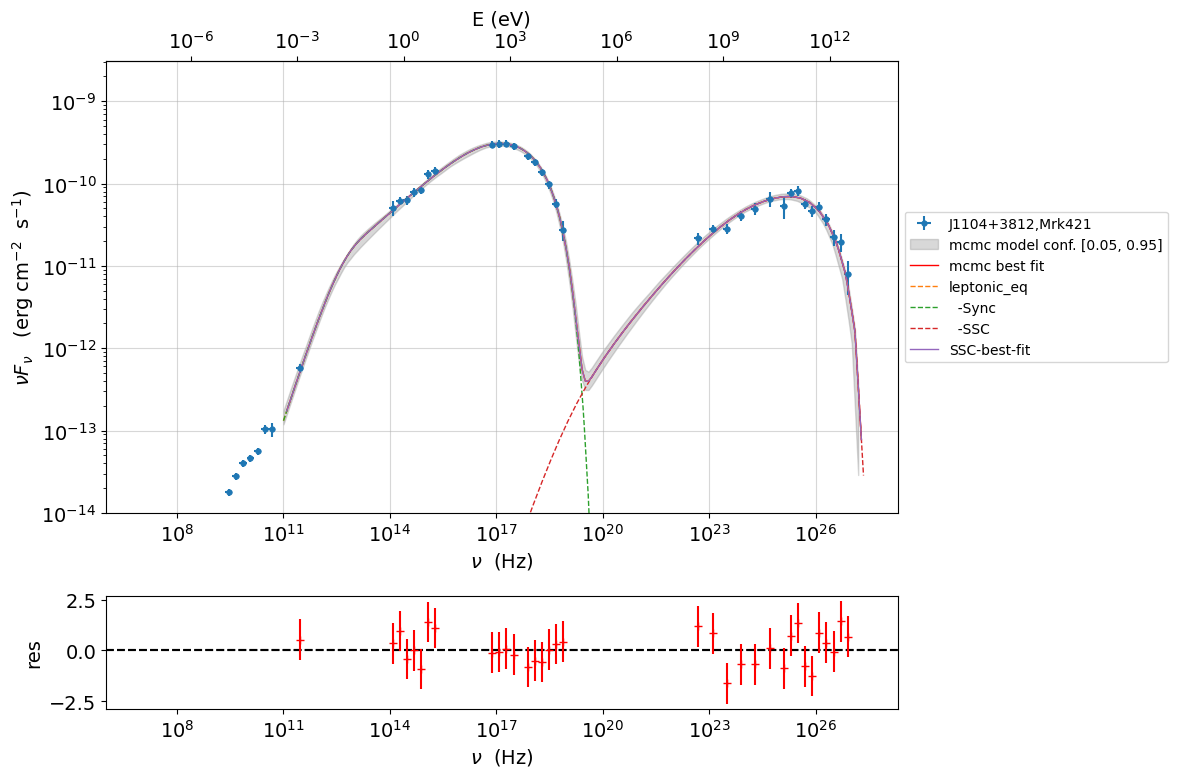

In [57]:
mpl.rcParams['figure.dpi'] = 80
p=ms.plot_model(sed_data=sed_data,size=100,quantiles=[0.05,0.95],plot_mcmc_best_fit_model=True)
p=ms.model.plot_model(plot_obj=p)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

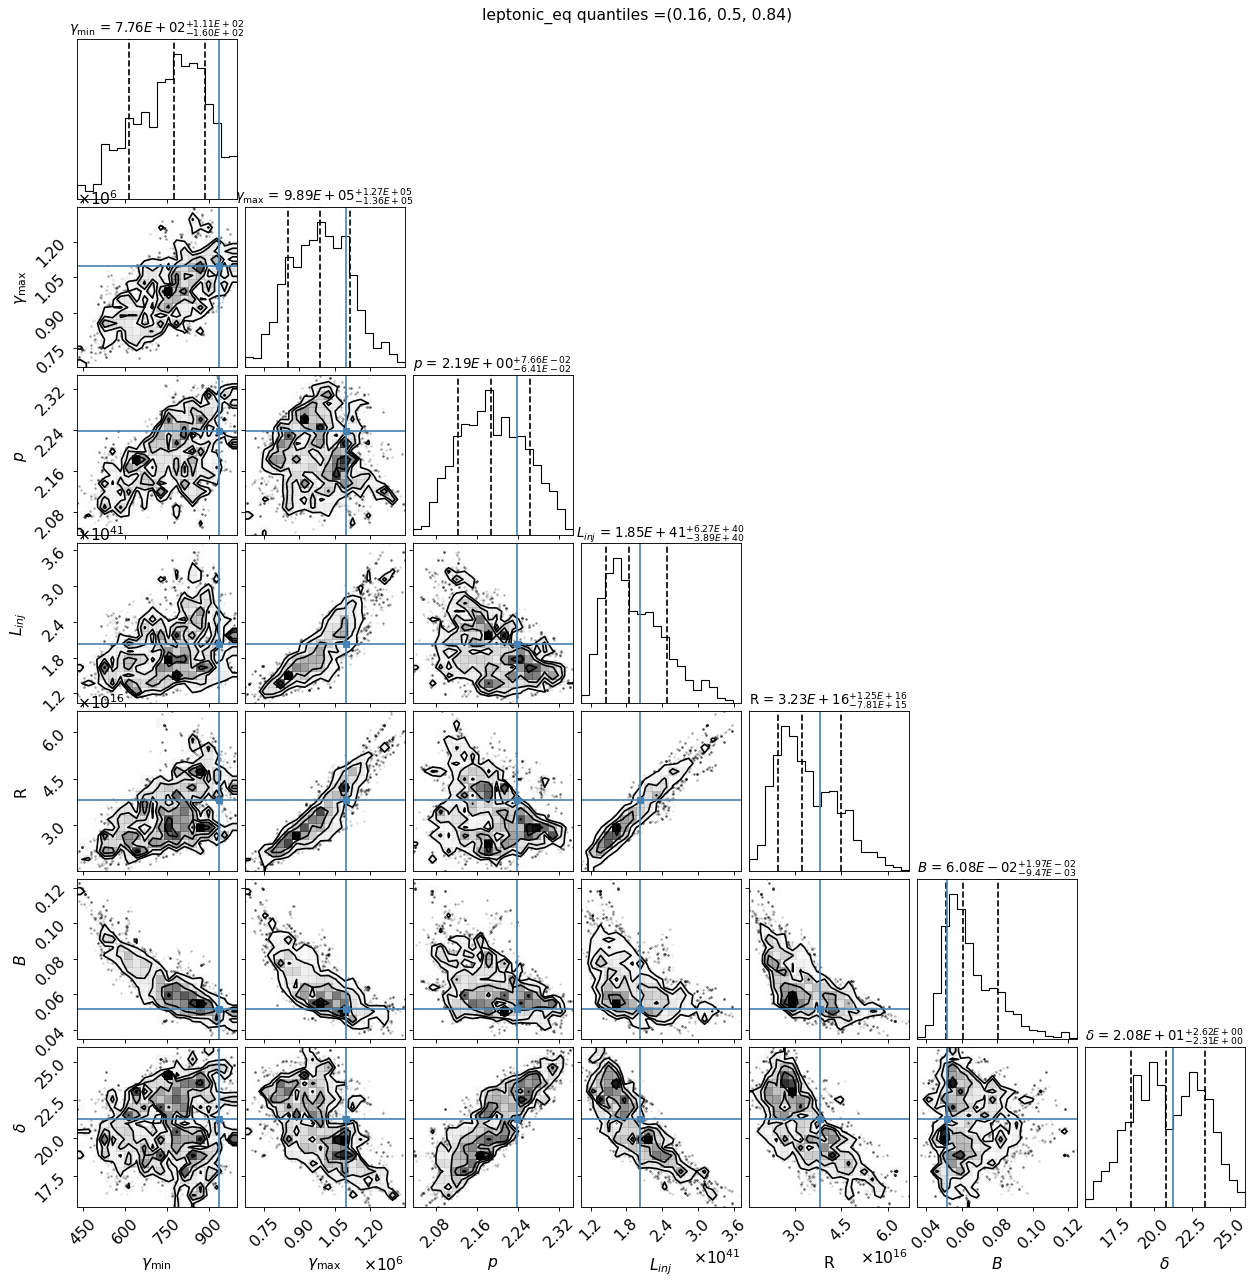

In [58]:
mpl.rcParams['figure.dpi'] = 80
f=ms.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True)

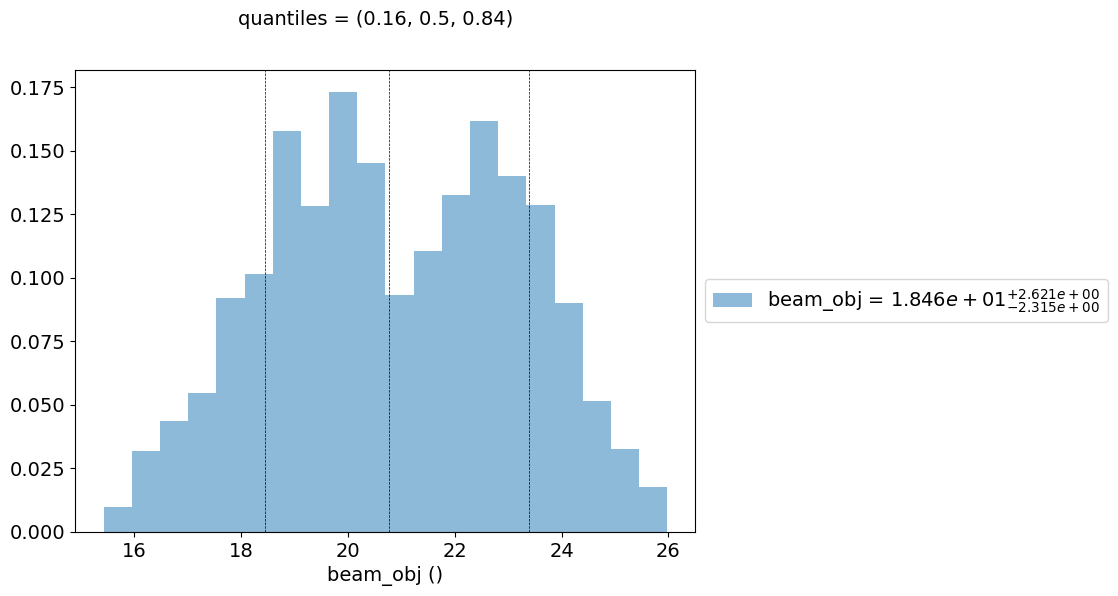

In [59]:
mpl.rcParams['figure.dpi'] = 80
f=ms.plot_par('beam_obj',log_plot=False,figsize=(8,6))

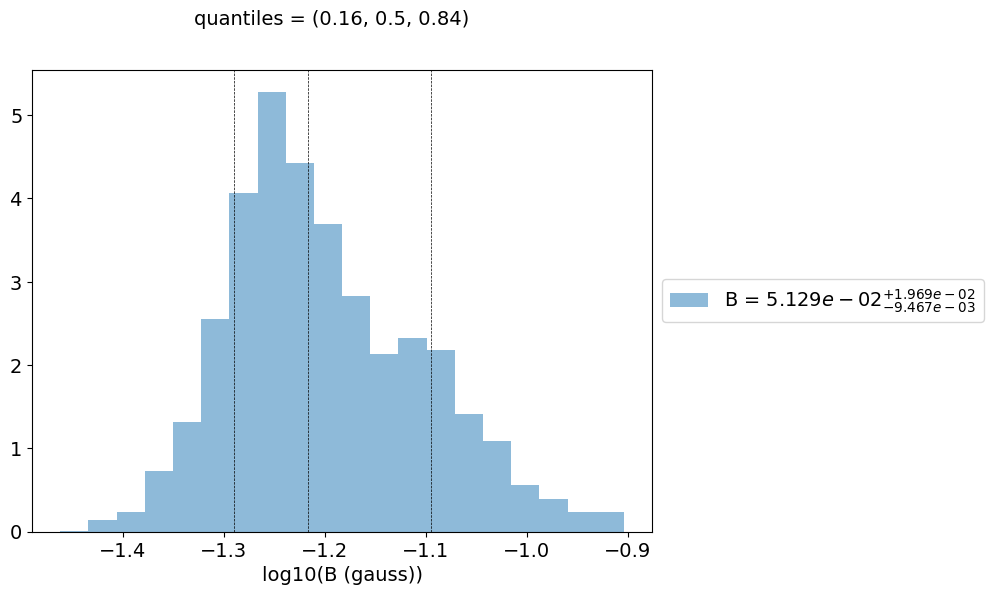

In [60]:
f=ms.plot_par('B',log_plot=True,figsize=(8,6))

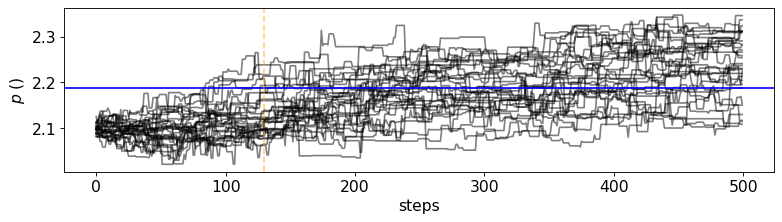

In [61]:
from matplotlib import pylab as plt
mpl.rcParams['figure.dpi'] = 80
f=ms.plot_chain(par_name='p',comp_name='leptonic_eq',log_plot=False)
plt.tight_layout()

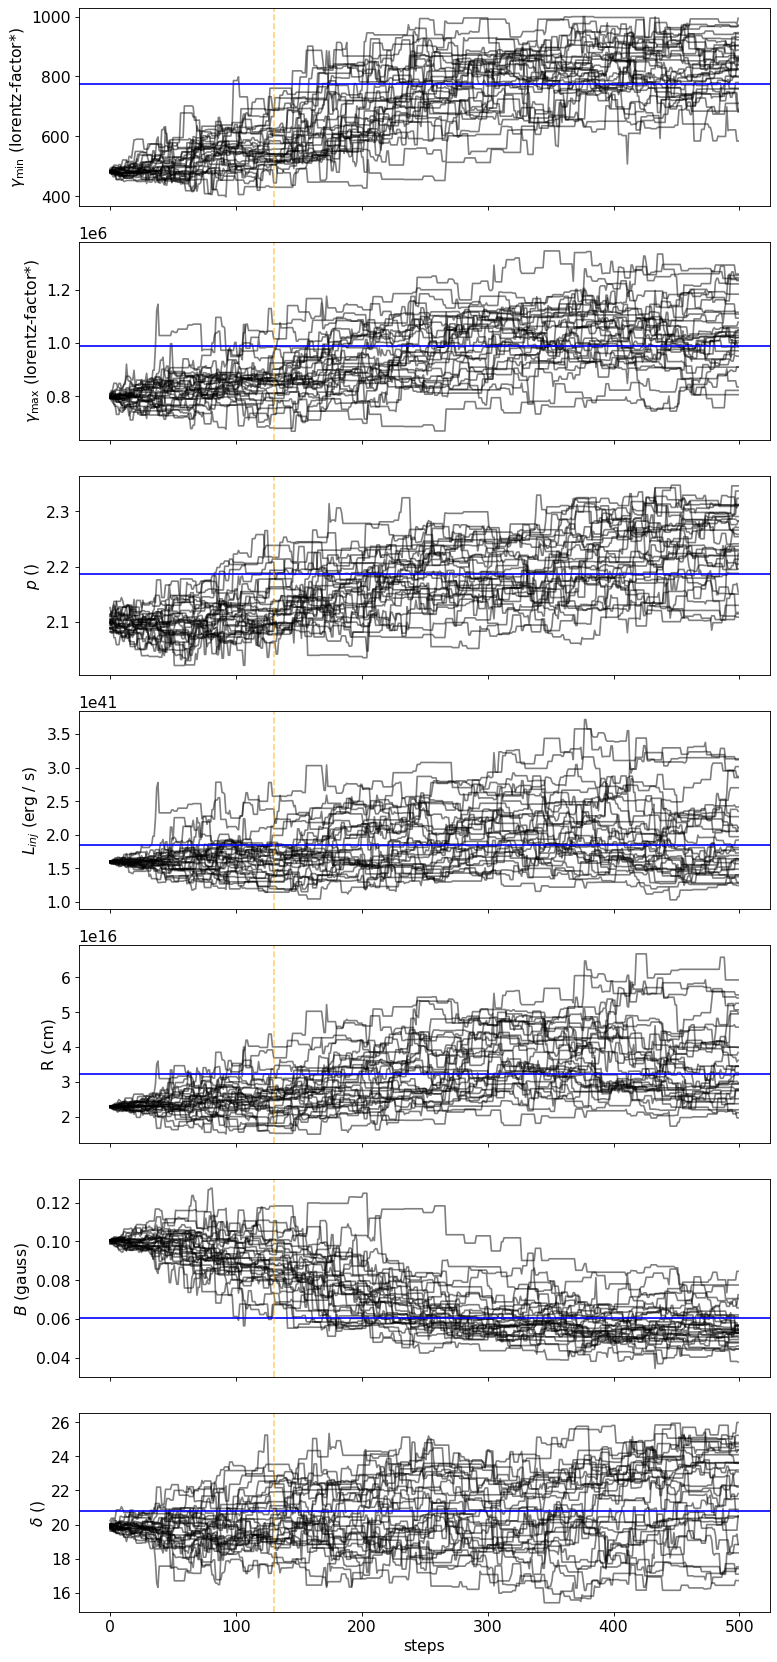

In [62]:
f=ms.plot_chain(log_plot=False)
plt.tight_layout()
mpl.rcParams['figure.dpi'] = 80